In [58]:
using Revise
using NMRlab
using DataFrames
using Plots

In [19]:
mlist=[
    "Glucose",
    "Lactic acid",
    "Alanine",
    "Leucine",
    "Valine",
    "Serine",
    "Isoleucine",
    "Pyruvic acid",
    "Citrate",
    "Phenylalanine",
    "Tyrosine",
    "Tryptophan",
    "Butyric acid",
    "Valeric acid",
    "Acetic acid",
    "Succinic acid",
    "glutaric acid",
    "ketoglutaric acid",
    "malic acid",
    "fumaric acid",
    "isocitric acid"
]

df=DataFrame("name"=>[],"id"=>[])
for M in mlist
    J=GISSMO.search(M)[1]
    push!(df,[J["name"],J["id"]])
end
df

Row,name,id
,Any,Any
1,(+/-)-Glucose,bmse000015
2,L-lactic-acid,bmse000208
3,L-alanine,bmse000028
4,L-leucine,bmse000042
5,L-valine,bmse000052
6,L-serine,bmse000048
7,L-Isoleucine,bmse000866
8,Pyruvic-acid,bmse000112
9,Citrate,bmse000076


In [ ]:
function gfid(id,t)
    n,H=GISSMO.Hamiltonian(id)
    rho0=sum(SpinSim.SpinOp(n,SpinSim.Sx,k) for k=1:n)
    Fp=sum(SpinSim.SpinOp(n,SpinSim.Sp,k) for k=1:n)
    freqs,ints=SpinSim.Spectrum(rho0,H,Fp)
    S = sum(i*exp.(-im*t*f) for (f,i) in zip(freqs,ints))
    return SpectData(S,(t,))
end

gfid (generic function with 1 method)

In [64]:
gfid("bmse000968",0:5.0e-5:0.5)

10001-element SpectData{ComplexF64, 1} with coords:(0.0:5.0e-5:0.5,):
                 16.0 + 0.0im
   14.596258452262488 - 6.5535669062546305im
   10.631345100655514 - 11.95719454348586im
    4.800974145782813 - 15.262720833833166im
  -1.8718126688460055 - 15.890132703434151im
   -8.216156831869752 - 13.729339638675999im
  -13.118830906440621 - 9.159491014691717im
  -15.719573980872287 - 2.9824476290260336im
  -15.562039666593446 + 3.717918962991535im
  -12.673870146372558 + 9.765910890075054im
                      ⋮
   11.822182373088067 - 10.7812802550275im
    6.368986743812319 - 14.67773851303882im
 -0.20176029912662732 - 15.998727848853997im
   -6.737104927744552 - 14.512457310619729im
   -12.09030529404397 - 10.4797193615484im
  -15.322047677080024 - 4.608129227928258im
  -15.865265695027594 + 2.072038712519765im
  -13.624642135224445 + 8.388630799306084im
   -8.993334045639044 + 13.233289188389623im

In [83]:
process=Chain(
    ZeroFill([2<<15]),
    Apodize([2.5π]),
    FourierTransform([2<<15],[1])
)

FourierTransform(Integer[1], Integer[65536], true, FFTW forward plan for 65536-element array of ComplexF64
(dft-ct-dit/32
  (dftw-direct-32/8 "t3fv_32_avx2_128")
  (dft-vrank>=1-x32/1
    (dft-ct-dit/32
      (dftw-direct-32/8 "t3fv_32_avx2_128")
      (dft-direct-64-x32 "n2fv_64_avx2_128"))))) ∘ Apodize(Union{Colon, Real}[7.853981633974483]) ∘ ZeroFill(Union{Colon, Integer}[65536])

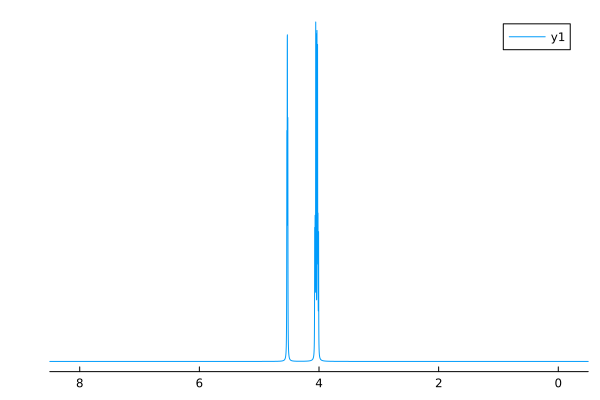

In [89]:
s = gfid("bmse000002",0:10.0e-5:1.0) |> process
plot(NMRlab.coords(s,1)/600 .+ 4.8,
    real(s),
    xaxis=:flip,
    yaxis=false,
    grid=false,
    xlims=[-0.5,8.5])